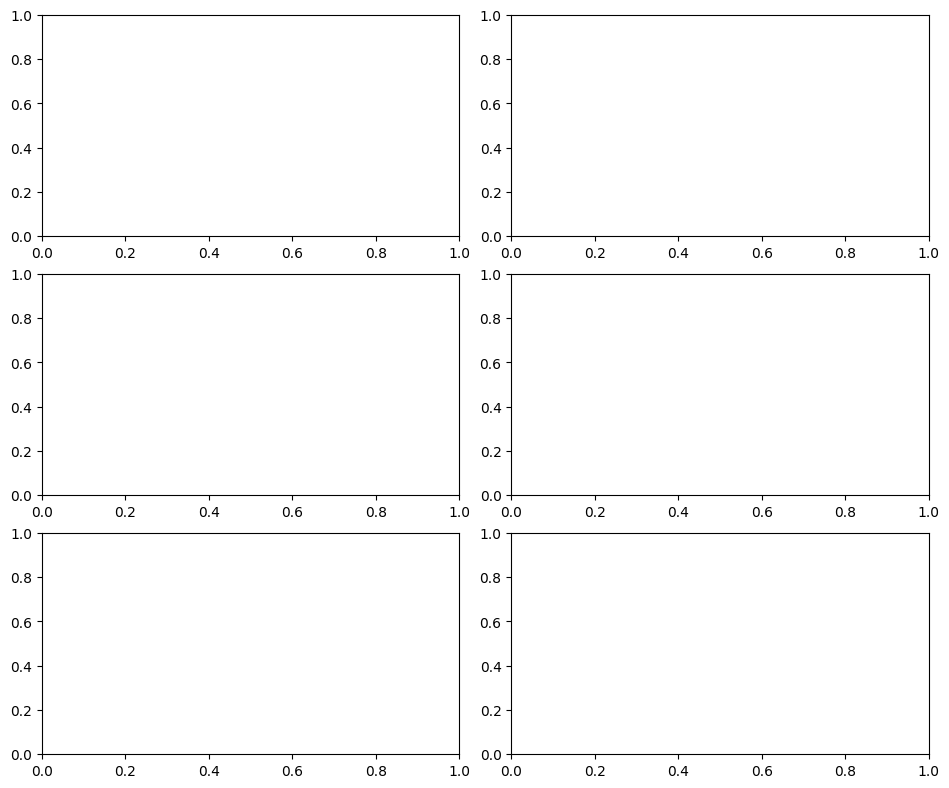

In [ ]:
import tkinter as tk
from tkinter import filedialog, ttk
from obspy import read
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

# -------------------------
# Model Q(Δ,h) (practical)
# -------------------------
def Q_delta_h(delta_deg, h_km):
    return 0.0035 * delta_deg + 0.002 * h_km + 1.0

# -------------------------
# Rumus magnitudo
# -------------------------
def compute_Ms(Vmax, delta_deg):
    # Vmax expected in same unit (e.g. mm/s) after scale correction
    return np.log10(Vmax / (2.0 * np.pi)) + 1.66 * np.log10(delta_deg) + 0.3

def compute_mb(Vmax, delta_deg, h_km):
    return np.log10(Vmax / (2.0 * np.pi)) + Q_delta_h(delta_deg, h_km) - 3.0

def compute_ML(A_mm, R_km):
    return np.log10(A_mm) + 1.11 * np.log10(R_km) + 0.00189 * R_km - 2.09

# -------------------------
# Utility
# -------------------------
def peak_amplitude(trace):
    return np.max(np.abs(trace.data.astype(float)))

# -------------------------
# GUI
# -------------------------
class MagApp:
    def __init__(self, root):
        self.root = root
        root.title("Perhitungan ML, Ms, mb dari MSEED")
        root.geometry("1300x900")

        # Left side: vertical split -> top=input, bottom=results
        left_frame = tk.Frame(root)
        left_frame.pack(side="left", fill="y", padx=8, pady=8)

        input_frame = tk.LabelFrame(left_frame, text="INPUT", padx=8, pady=8, bg="#E7F0FF")
        input_frame.pack(fill="x")

        # --- ML inputs (3 files) ---
        tk.Label(input_frame, text="ML — pilih 3 file MSEED dan masukkan jarak R (km) serta scale (counts->mm)", bg="#E7F0FF").pack(anchor="w")
        self.ml_file_vars = [tk.StringVar() for _ in range(3)]
        self.ml_R_vars = [tk.StringVar(value="100") for _ in range(3)]
        self.ml_scale_vars = [tk.StringVar(value="0.001") for _ in range(3)]  # default counts->mm

        for i in range(3):
            row = tk.Frame(input_frame, bg="#E7F0FF")
            row.pack(fill="x", pady=2)
            tk.Entry(row, textvariable=self.ml_file_vars[i], width=46).pack(side="left", padx=2)
            tk.Button(row, text="Pilih", command=lambda v=self.ml_file_vars[i]: self.pick_file(v)).pack(side="left", padx=2)
            tk.Label(row, text="R (km)", bg="#E7F0Ff").pack(side="left", padx=4)
            tk.Entry(row, textvariable=self.ml_R_vars[i], width=6).pack(side="left", padx=2)
            tk.Label(row, text="scale→mm", bg="#E7F0FF").pack(side="left", padx=4)
            tk.Entry(row, textvariable=self.ml_scale_vars[i], width=8).pack(side="left", padx=2)

        tk.Label(input_frame, text=" ", bg="#E7F0FF").pack()  # spacer

        # --- Ms & mb inputs (3 files) ---
        tk.Label(input_frame, text="Ms & mb — pilih 3 file MSEED, masukkan Δ (deg). Global h (km) untuk mb, dan scale (counts->unit)", bg="#E7F0FF").pack(anchor="w")
        self.msmb_file_vars = [tk.StringVar() for _ in range(3)]
        self.msmb_delta_vars = [tk.StringVar(value="10") for _ in range(3)]
        self.msmb_scale_vars = [tk.StringVar(value="0.001") for _ in range(3)]  # default scale counts->mm/s

        for i in range(3):
            row = tk.Frame(input_frame, bg="#E7F0FF")
            row.pack(fill="x", pady=2)
            tk.Entry(row, textvariable=self.msmb_file_vars[i], width=46).pack(side="left", padx=2)
            tk.Button(row, text="Pilih", command=lambda v=self.msmb_file_vars[i]: self.pick_file(v)).pack(side="left", padx=2)
            tk.Label(row, text="Δ (deg)", bg="#E7F0FF").pack(side="left", padx=4)
            tk.Entry(row, textvariable=self.msmb_delta_vars[i], width=6).pack(side="left", padx=2)
            tk.Label(row, text="scale→unit", bg="#E7F0FF").pack(side="left", padx=4)
            tk.Entry(row, textvariable=self.msmb_scale_vars[i], width=8).pack(side="left", padx=2)

        # kedalaman h global untuk mb
        h_frame = tk.Frame(input_frame, bg="#E7F0FF")
        h_frame.pack(fill="x", pady=6)
        tk.Label(h_frame, text="Kedalaman h (km) untuk mb:", bg="#E7F0FF").pack(side="left")
        self.h_var = tk.StringVar(value="50")
        tk.Entry(h_frame, textvariable=self.h_var, width=8).pack(side="left", padx=6)

        # tombol hitung
        tk.Button(input_frame, text="Hitung Magnitudo", bg="#FFA500", command=self.compute_all).pack(pady=8)

        # Results 
        result_frame = tk.LabelFrame(left_frame, text="HASIL PERHITUNGAN", padx=8, pady=8, bg="#FFF5F5")
        result_frame.pack(fill="both", expand=True, pady=10)

        self.result_text = tk.Text(result_frame, height=12, width=60, font=("Courier", 11))
        self.result_text.pack(fill="both", expand=True)

        # Right side: big plot area (all plots here)
        right_frame = tk.Frame(root)
        right_frame.pack(side="right", fill="both", expand=True, padx=8, pady=8)

        # Make 6 subplots: top 3 for ML traces, bottom 3 for Ms/Mb traces
        self.fig, axs = plt.subplots(3, 2, figsize=(9, 10), constrained_layout=True)
        # left column: ML traces (3), right column: Ms/Mb traces (3)
        self.canvas = FigureCanvasTkAgg(self.fig, master=right_frame)
        self.canvas.get_tk_widget().pack(fill="both", expand=True)

    def pick_file(self, var):
        file = filedialog.askopenfilename(filetypes=[("MSEED", "*.mseed"), ("All files", "*.*")])
        if file:
            var.set(file)

    def compute_all(self):
        self.result_text.delete("1.0", tk.END)
        # clear plots
        for i in range(3):
            for j in range(2):
                self.fig.axes[i*2 + j].clear() if False else None  # no-op -> we clear via ax.clear below
        for i in range(3):
            self.fig.axes[i*2].clear() if False else None
        for ax in self.fig.axes:
            ax.clear()

        try:
            # ----- ML processing -----
            ml_vals = []
            for i in range(3):
                f = self.ml_file_vars[i].get().strip()
                if f == "":
                    raise ValueError(f"File ML stasiun {i+1} belum dipilih")
                R = float(self.ml_R_vars[i].get())
                scale = float(self.ml_scale_vars[i].get())  # counts -> mm
                st = read(f)
                tr = st[0]
                Vpeak = peak_amplitude(tr)   # counts
                A_mm = Vpeak * scale         # convert to mm
                ml = compute_ML(A_mm, R)
                ml_vals.append(ml)
                # plot to left column (col 0)
                ax = self.fig.axes[i*2] if False else self.fig.axes[i*2] if False else self.fig.axes[i]  # use axes rows properly
                # but safer: axes is 3x2 -> axs[i,0]
                self.ax = self.fig.axes  # not necessary, we'll use axs 2D saved earlier
                axs_local = np.array(self.fig.axes).reshape(3,2)
                axs_local[i,0].plot(tr.times(), tr.data)
                axs_local[i,0].set_title(f"ML - Stasiun {i+1}")
                axs_local[i,0].grid(True)

            # ----- Ms & mb processing -----
            h_km = float(self.h_var.get())
            ms_vals = []
            mb_vals = []
            axs_local = np.array(self.fig.axes).reshape(3,2)
            for i in range(3):
                f = self.msmb_file_vars[i].get().strip()
                if f == "":
                    raise ValueError(f"File Ms/Mb stasiun {i+1} belum dipilih")
                delta = float(self.msmb_delta_vars[i].get())
                scale = float(self.msmb_scale_vars[i].get())  # counts -> unit (e.g. mm/s)
                st = read(f)
                tr = st[0]
                Vpeak = peak_amplitude(tr)
                Vmax_unit = Vpeak * scale
                ms = compute_Ms(Vmax_unit, delta)
                mb = compute_mb(Vmax_unit, delta, h_km)
                ms_vals.append(ms)
                mb_vals.append(mb)
                axs_local[i,1].plot(tr.times(), tr.data)
                axs_local[i,1].set_title(f"Ms/Mb - Stasiun {i+1}")
                axs_local[i,1].grid(True)

            # show averages & per-station results
            out = []
            out.append("=== HASIL PER STASIUN ===")
            for i in range(len(ml_vals)):
                out.append(f"ML st{ i+1 } : {ml_vals[i]:.3f}")
            out.append(f"ML rata-rata : {np.mean(ml_vals):.3f}")
            out.append("")
            for i in range(len(ms_vals)):
                out.append(f"Ms st{ i+1 } : {ms_vals[i]:.3f}    mb st{ i+1 } : {mb_vals[i]:.3f}")
            out.append(f"Ms rata-rata : {np.mean(ms_vals):.3f}")
            out.append(f"mb rata-rata : {np.mean(mb_vals):.3f}")

            self.result_text.insert("1.0", "\n".join(out))

            # redraw canvas
            self.canvas.draw()

        except Exception as e:
            self.result_text.insert("1.0", f"ERROR: {e}\n")
            return

# Run app
if __name__ == "__main__":
    root = tk.Tk()
    app = MagApp(root)
    root.mainloop()
